In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

from sklearn.metrics import (confusion_matrix, classification_report, precision_score, recall_score)

import warnings
warnings.filterwarnings('ignore')

In [8]:
dataset_path = "C:/Users/roopt/Capstone_Medical_Image_Diagnosis_Using_Deep_Learning/Dataset/chest_xray"

# Train, Test and Validation folders
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")
val_path = os.path.join(dataset_path, "val")

# Dataset Structure Analysis
This step counts the number of images present in each class across the training, testing, and validation folders.
The dataset contains two classes: NORMAL and PNEUMONIA.
The training dataset contains more pneumonia images than normal images, indicating class imbalance.

In [9]:
# Counting images in train, test and validation folder

def count_images(folder_path):
    count = 0

    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)

        if os.path.isdir(class_folder):
            num_images = len(os.listdir(class_folder))
            count += num_images

            print(f"{class_name}: {num_images} images")

    print(f"\nTotal Images: {count}\n")


print("===== TRAIN DATA =====")
count_images(train_path)

print("===== TEST DATA =====")
count_images(test_path)

print("===== VALIDATION DATA =====")
count_images(val_path)

===== TRAIN DATA =====
NORMAL: 1341 images
PNEUMONIA: 3875 images

Total Images: 5216

===== TEST DATA =====
NORMAL: 234 images
PNEUMONIA: 390 images

Total Images: 624

===== VALIDATION DATA =====
NORMAL: 8 images
PNEUMONIA: 8 images

Total Images: 16



Sample Image Visualization - Visualize sample images from both classes (NORMAL and PNEUMONIA) to understand the dataset.

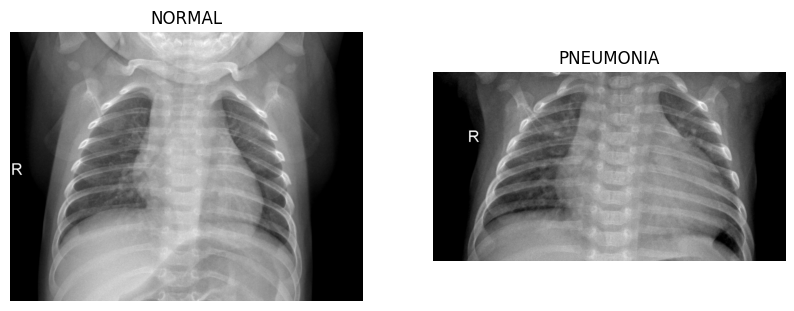

In [11]:
import random
from tensorflow.keras.preprocessing.image import load_img

# Class folders
normal_folder = os.path.join(train_path, "NORMAL")
pneumonia_folder = os.path.join(train_path, "PNEUMONIA")

# Random image selection
normal_image = random.choice(os.listdir(normal_folder))
pneumonia_image = random.choice(os.listdir(pneumonia_folder))

# Full paths
normal_path = os.path.join(normal_folder, normal_image)
pneumonia_path = os.path.join(pneumonia_folder, pneumonia_image)

# Load images
img_normal = load_img(normal_path)
img_pneumonia = load_img(pneumonia_path)

# Display images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_normal, cmap='gray')
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_pneumonia, cmap='gray')
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

Image Dimension Analysis - Analyzing the dimensions of sample images from the dataset.

In [12]:
from tensorflow.keras.preprocessing.image import load_img
import os
import random

# Random images
normal_image = random.choice(os.listdir(normal_folder))
pneumonia_image = random.choice(os.listdir(pneumonia_folder))

# Load images
normal_img = load_img(os.path.join(normal_folder, normal_image))
pneumonia_img = load_img(os.path.join(pneumonia_folder, pneumonia_image))

# Print dimensions
print("NORMAL Image Size:", normal_img.size)
print("PNEUMONIA Image Size:", pneumonia_img.size)

NORMAL Image Size: (1522, 1090)
PNEUMONIA Image Size: (1128, 680)


Image Preprocessing and Data Augmentation - Preparing the chest X-ray images for CNN training by applying preprocessing and augmentation techniques.

Preprocessing Steps:
1. Resize all images to 224 × 224 pixels.
2. Normalize pixel values between 0 and 1.
3. Apply data augmentation to increase training data diversity.

In [17]:
# Image Data Generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training Data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Validation Data
val_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Testing Data
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [16]:
train_generator.class_indices

{'NORMAL': 0, 'PNEUMONIA': 1}

Verification of Preprocessed Data - Verifying that image preprocessing has been applied correctly.
Checks:
    Images are resized to 224 × 224 pixels.
    Pixel values are normalized between 0 and 1.
    Batch dimensions are suitable for CNN training.

In [18]:
images, labels = next(train_generator)

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

print("\nMinimum Pixel Value :", images.min())
print("Maximum Pixel Value :", images.max())

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


Building a Convolutional Neural Network (CNN) for pneumonia detection from chest X-ray images.

CNN Architecture:
    Convolution Layers (Feature Extraction)
    Max Pooling Layers (Dimensionality Reduction)
    Flatten Layer (Convert Feature Maps to 1D)
    Dense Layers (Classification)
    Dropout Layer (Prevent Overfitting)
    Output Layer (Binary Classification)

In [19]:
# CNN Model

model = Sequential([

    # First Convolution Block
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Block
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Block
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(
        128,
        activation='relu'
    ),

    # Dropout
    Dropout(0.5),

    # Output Layer
    Dense(
        1,
        activation='sigmoid'
    )
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Model Compilation
Configure the CNN model for training by defining:
    Optimizer - Adam - provides efficient weight updates and faster convergence.
    Loss Function - Binary Crossentropy - suitable for binary classification problems where the output classes are NORMAL and PNEUMONIA.
    Evaluation Metric - Accuracy - used to measure overall classification performance.

In [21]:
# Compile the CNN Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

CNN Model Training:
Train the CNN model using the preprocessed chest X-ray images.



In [22]:
# Train CNN Model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.7692 - loss: 0.6655 - val_accuracy: 0.6875 - val_loss: 0.5337
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.8911 - loss: 0.2571 - val_accuracy: 0.8125 - val_loss: 0.5703
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9063 - loss: 0.2302 - val_accuracy: 0.8125 - val_loss: 0.4437
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9171 - loss: 0.2069 - val_accuracy: 0.8125 - val_loss: 0.6109
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9258 - loss: 0.1867 - val_accuracy: 0.8125 - val_loss: 0.4765
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.9356 - loss: 0.1809 - val_accuracy: 0.6875 - val_loss: 0.8475
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9353 - loss: 0.1776 - val_accuracy: 0.6250 - val_loss: 1.1394
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9376 - loss: 0.1792 - val_accu

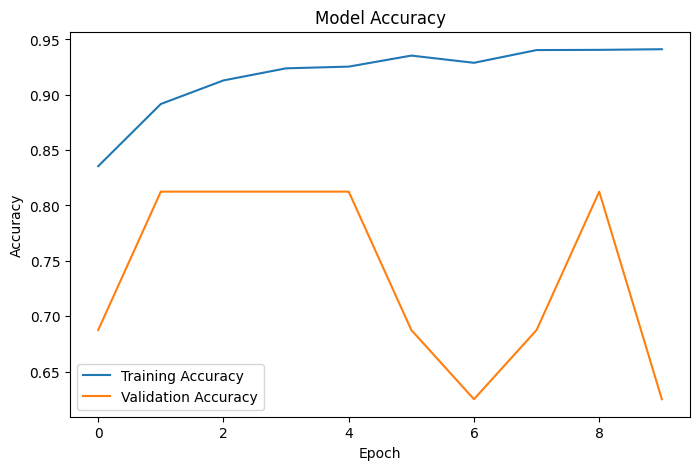

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

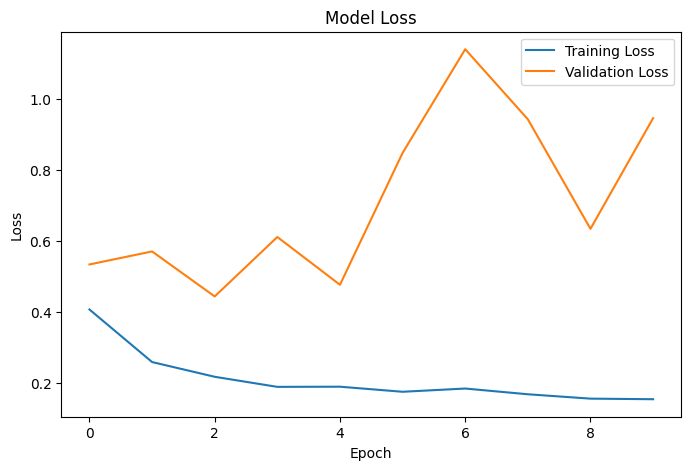

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [25]:
# Evaluate on test data

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 944ms/step - accuracy: 0.6842 - loss: 0.7260

Test Loss: 0.4299
Test Accuracy: 0.8253


In [26]:
# Generate predictions

y_pred_prob = model.predict(test_generator)

# Convert probabilities to classes
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = test_generator.classes

print("Predictions Generated Successfully!")

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 418ms/step
Predictions Generated Successfully!


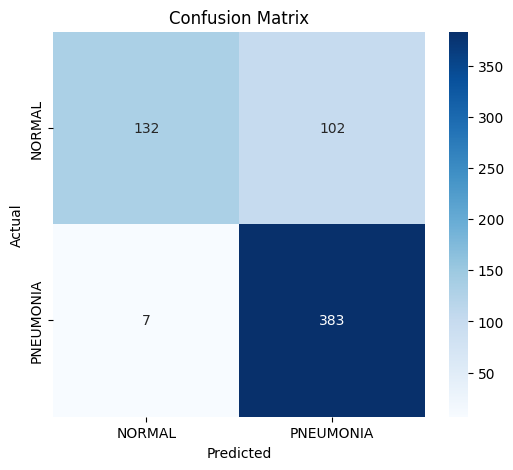

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL','PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.95      0.56      0.71       234
   PNEUMONIA       0.79      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.77      0.79       624
weighted avg       0.85      0.83      0.81       624



Classification Report of Custom CNN

The Custom CNN model achieved an overall test accuracy of **82.53%**.

The model demonstrated excellent recall for Pneumonia detection (98%), indicating that most pneumonia cases were correctly identified. However, the recall for Normal images was comparatively lower (56%), suggesting that some normal chest X-rays were incorrectly classified as Pneumonia.

This behavior is likely influenced by the class imbalance present in the dataset, where pneumonia images significantly outnumber normal images.

Overall, the Custom CNN successfully learned disease-related features but showed limitations in generalizing across both classes.


Model 2: MobileNetV2 Transfer Learning
    To improve classification performance using a pre-trained deep learning model.
    MobileNetV2 is a lightweight and efficient Convolutional Neural Network that has been pre-trained on a large image dataset (ImageNet).
    Advantages: 
        Faster convergence
        Better feature extraction
        Reduced training time
        Improved classification accuracy

In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

In [34]:
# Load pretrained MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers

base_model.trainable = False

In [35]:
mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

])

In [36]:
mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [39]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8544 - loss: 0.3560 - val_accuracy: 0.8125 - val_loss: 0.3573
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9404 - loss: 0.1492 - val_accuracy: 0.8125 - val_loss: 0.2996
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9483 - loss: 0.1305 - val_accuracy: 0.8125 - val_loss: 0.4205
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.9555 - loss: 0.1153 - val_accuracy: 0.8125 - val_loss: 0.3908
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9591 - loss: 0.1031 - val_accuracy: 0.8125 - val_loss: 0.2832


In [40]:
test_loss_mobile, test_acc_mobile = mobilenet_model.evaluate(test_generator)

print(f"\nMobileNetV2 Test Loss: {test_loss_mobile:.4f}")
print(f"MobileNetV2 Test Accuracy: {test_acc_mobile:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 708ms/step - accuracy: 0.8226 - loss: 0.4169

MobileNetV2 Test Loss: 0.2871
MobileNetV2 Test Accuracy: 0.8830


In [41]:
y_pred_prob_mobile = mobilenet_model.predict(test_generator)

y_pred_mobile = (y_pred_prob_mobile > 0.5).astype(int)

y_true = test_generator.classes

print("Predictions Generated Successfully!")


20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 821ms/step
Predictions Generated Successfully!


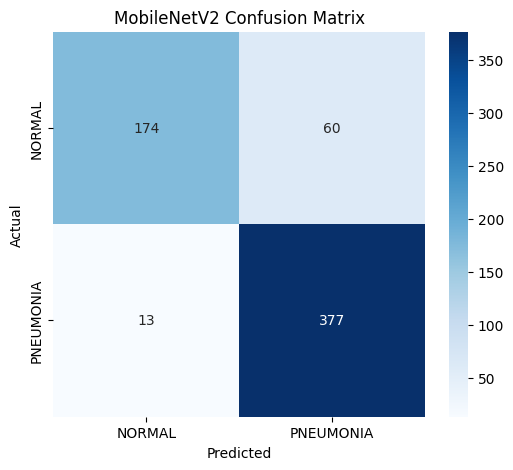

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_mobile = confusion_matrix(y_true, y_pred_mobile)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_mobile,
        target_names=['NORMAL','PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.93      0.74      0.83       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624



Classification Report of MobileNetV2

The MobileNetV2 model achieved the highest test accuracy of **88.30%** among all evaluated models.

Compared to the Custom CNN, MobileNetV2 significantly improved the classification of Normal images while maintaining strong performance in detecting Pneumonia cases.

The model achieved high precision, recall, and F1-score values, indicating balanced classification performance across both classes.

The results demonstrate the effectiveness of Transfer Learning in extracting meaningful image features and improving medical image diagnosis performance.

Based on test dataset performance, MobileNetV2 was selected as the final model for deployment.


Model 3: Improved MobileNetV2
    Further improve the performance of MobileNetV2 through optimized validation strategies and training techniques.
    Improvements Applied
        Validation Split (20%)
        Early Stopping
        Learning Rate Reduction
        Model Checkpointing
        Additional Dense Layers

In [54]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_v2 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator_v2 = train_datagen_v2.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator_v2 = train_datagen_v2.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


In [55]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [56]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_mobilenet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [58]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

base_model_v2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_v2.trainable = False

improved_mobilenet_model = Sequential([
    base_model_v2,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

In [ ]:
improved_mobilenet_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [60]:
improved_mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [61]:
history_improved = improved_mobilenet_model.fit(
    train_generator_v2,
    validation_data=val_generator_v2,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8525 - loss: 0.3256
Epoch 1: val_accuracy improved from -inf to 0.94535, saving model to best_mobilenet_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.8528 - loss: 0.3249 - val_accuracy: 0.9453 - val_loss: 0.1460 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.9262 - loss: 0.1863
Epoch 2: val_accuracy did not improve from 0.94535
131/131 ━━━━━━━━━━━━━━━━━━━━ 131s 1000ms/step - accuracy: 0.9262 - loss: 0.1862 - val_accuracy: 0.9453 - val_loss: 0.1221 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9461 - loss: 0.1519
Epoch 3: val_accuracy improved from 0.94535 to 0.95110, saving model to best_mobilenet_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 975ms/step - accuracy: 0.9461 - loss: 0.1518 - val_accuracy: 0.9511 - val_loss: 0.1263 - learning_rate: 0.0010
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accu

In [62]:
test_loss_improved, test_acc_improved = improved_mobilenet_model.evaluate(
    test_generator
)

print(f"\nImproved MobileNetV2 Test Loss: {test_loss_improved:.4f}")
print(f"Improved MobileNetV2 Test Accuracy: {test_acc_improved:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 660ms/step - accuracy: 0.8117 - loss: 0.4868

Improved MobileNetV2 Test Loss: 0.3144
Improved MobileNetV2 Test Accuracy: 0.8782


In [63]:
y_pred_prob_improved = improved_mobilenet_model.predict(
    test_generator
)

y_pred_improved = (
    y_pred_prob_improved > 0.5
).astype(int)

y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 643ms/step


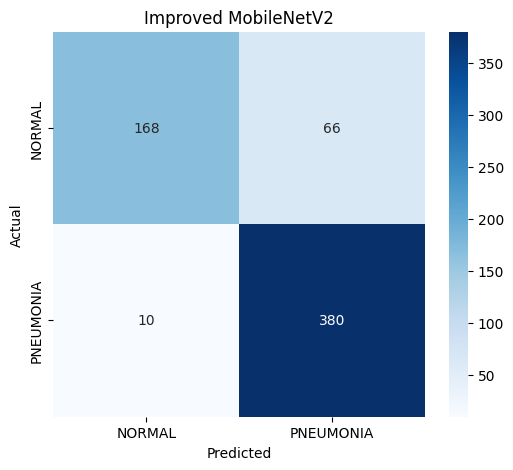

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_improved = confusion_matrix(
    y_true,
    y_pred_improved
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL','PNEUMONIA'],
    yticklabels=['NORMAL','PNEUMONIA']
)

plt.title("Improved MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [68]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_improved,
        target_names=[
            'NORMAL',
            'PNEUMONIA'
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.94      0.72      0.82       234
   PNEUMONIA       0.85      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.86       624
weighted avg       0.89      0.88      0.87       624



Classification Report of Improved MobileNetV2

The Improved MobileNetV2 model achieved a test accuracy of **87.82%**.

Although the model obtained higher training and validation accuracy compared to the original MobileNetV2, the performance on the unseen test dataset was slightly lower.

This indicates that the additional training optimizations improved learning on the training and validation data but did not translate into better generalization on completely unseen images.

The results highlight the importance of evaluating models using an independent test dataset rather than relying solely on validation accuracy.

Therefore, the original MobileNetV2 remained the preferred model due to its superior test performance.


Model Comparison:
    Compare the performance of all implemented approaches and identify the most suitable model for deployment.

In [69]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Custom CNN',
        'MobileNetV2',
        'Improved MobileNetV2'
    ],
    'Accuracy': [
        82.53,
        88.30,
        round(test_acc_improved*100,2)
    ]
})

comparison

,Model,Accuracy
0,Custom CNN,82.53
1,MobileNetV2,88.30
2,Improved MobileNetV2,87.82


Conclusion:

This project successfully developed a Deep Learning-based Medical Image Diagnosis System for Pneumonia detection using Chest X-ray images.

Three different CNN-based approaches were implemented and evaluated. The Custom CNN achieved a test accuracy of 82.53%, while MobileNetV2 improved the performance to 88.30%. An Improved MobileNetV2 model was also developed using advanced training techniques; however, the original MobileNetV2 achieved the best performance on the unseen test dataset.

The results demonstrate that Transfer Learning significantly improves medical image classification performance compared to a CNN trained from scratch.

The developed system successfully classifies Chest X-ray images into Normal and Pneumonia categories, thereby assisting healthcare professionals in faster and more reliable disease diagnosis.

Based on experimental evaluation, MobileNetV2 was selected as the final model due to its superior test accuracy and generalization capability.


In [44]:
mobilenet_model.save("pneumonia_detection_model.h5")

In [2]:
from tensorflow.keras.models import load_model

loaded_model = load_model("pneumonia_detection_model.h5")

In [3]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_pneumonia(img_path):

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    prediction = loaded_model.predict(img_array)

    probability = prediction[0][0]

    if probability > 0.5:

        print("\nPrediction: PNEUMONIA")
        print(f"Confidence: {probability*100:.2f}%")

    else:

        print("\nPrediction: NORMAL")
        print(f"Confidence: {(1-probability)*100:.2f}%")

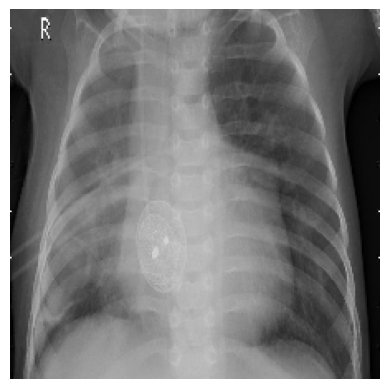

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

Prediction: PNEUMONIA
Confidence: 99.99%


In [52]:
sample_image = "C:/Users/roopt/Capstone_Medical_Image_Diagnosis_Using_Deep_Learning/Dataset/chest_xray/test/PNEUMONIA/person85_bacteria_423.jpeg"

predict_pneumonia(sample_image)

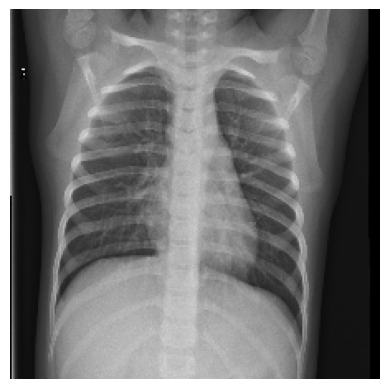

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

Prediction: NORMAL
Confidence: 97.82%


In [53]:
sample_image = "C:/Users/roopt/Capstone_Medical_Image_Diagnosis_Using_Deep_Learning/Dataset/chest_xray/test/NORMAL/NORMAL2-IM-0079-0001.jpeg"

predict_pneumonia(sample_image)

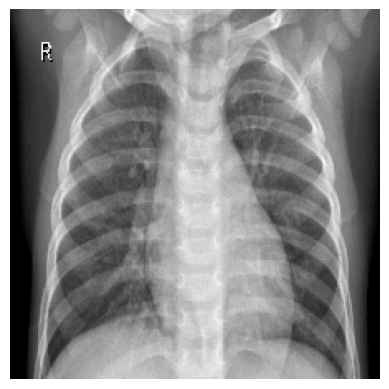

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Prediction: PNEUMONIA
Confidence: 59.36%


In [4]:
sample_image = "C:/Users/roopt/Capstone_Medical_Image_Diagnosis_Using_Deep_Learning/Dataset/chest_xray/test/NORMAL/IM-0085-0001.jpeg"

predict_pneumonia(sample_image)